# Description

Architecture and Strategy Summary

We've implemented a Hierarchical Classification pipeline.
The process involves three separate deep learning classifiers (C1, C2, C3), each trained independently with a single output unit for binary prediction. All models use the same data preprocessing pipeline: ROI extraction, Reinhard color normalization, and resizing. For the final prediction, we employ an Ensemble and Test-Time Augmentation (TTA) strategy: the final output for any given image is the average prediction across 5 trained folds (Cross-Validation) and 4 augmented views (TTA: original, flip H, flip V, rotate 90°), which minimizes variance and maximizes generalization.

The hierarchical flow is as follows: C1 first performs a Triage (Luminal Group vs. Aggressive Group). 
If C1 predicts Luminal, the sample is passed to C2 for Luminal Subtyping (Luminal A vs. Luminal B). 
If C1 predicts Aggressive, the sample is passed to C3 for Aggressive Subtyping (HER2(+) vs. Triple Negative). 

The hyperparameters were not yet tuned.

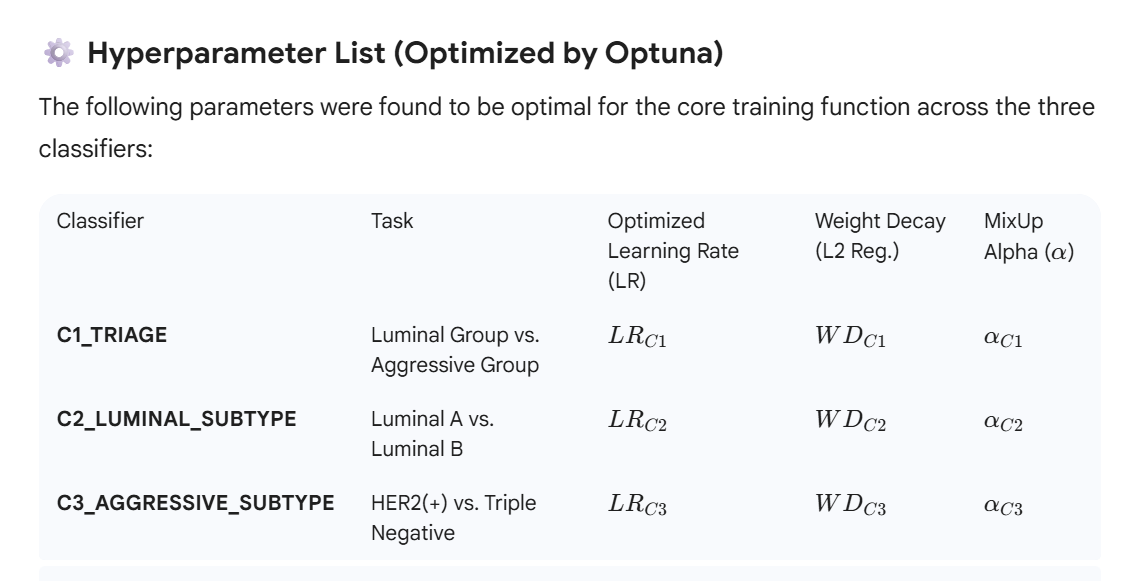

# Start

In [44]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.transforms import AutoAugment, AutoAugmentPolicy 

PRECOMPUTED_DIR = '/kaggle/working/precomputed_rois' # The location to save processed images



In [74]:
# --- 1. CONFIGURAZIONE ---
def find_paths():
    base_train = '/kaggle/input/dataset'
    # Cerca la cartella corretta per il test (che ha lo spazio nel nome)
    test_root = '/kaggle/input/test-data/test_data'
    # for root, dirs, files in os.walk('/kaggle/input'):
    #     if root.endswith("test-data/test_data"):
    #         test_root = root
    #         break
            
    if test_root is None:
        raise ValueError("Impossibile trovare la cartella test_data/images")

    return {
        'train_img': os.path.join(base_train, 'images'),
        'train_mask': os.path.join(base_train, 'masks'),
        'labels': os.path.join(base_train, 'train_labels.csv'),
        'test_img': os.path.join(test_root, 'test_img'),
        'test_mask': os.path.join(test_root, 'test_mask')
    }

PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Iperparametri Ottimizzati
IMG_SIZE = 256
BATCH_SIZE = 64
N_FOLDS = 5
EPOCHS = 35


In [46]:
# Global Default Hyperparameters (Used if a specific classifier doesn't override them)
DEFAULT_HPARAMS = {
    'LR': 1e-4, 
    'WEIGHT_DECAY': 3e-2, 
    'MIXUP_ALPHA': 0.5
}

# --- CLASSIFIER CONFIGURATIONS ---
# Define the three distinct tasks and their initial hyperparameters
CLASSIFIER_CONFIGS = {
    # C1: Triage (Aggressive vs. Luminal Group)
    'C1_TRIAGE': {
        'key': 'C1_TRIAGE',
        'name': 'C1_TRIAGE: Luminal vs. Aggressive',
        'group_0': ['Luminal A', 'Luminal B'],        # Class 0
        'group_1': ['HER2(+)', 'Triple negative'],     # Class 1
        'label_col': 'C1_label',
        'class_names': ['Luminal Group', 'Aggressive Group'],
        'hparams':{
            'LR': 5e-5,          # Lower LR for better convergence on subtle features
            'WEIGHT_DECAY': 3e-2,
            'MIXUP_ALPHA': 0.6   # Increased MixUp for better generalization
        }
    },
    
    # C2: Luminal Subtyping (Requires data where label is Luminal A or B)
    'C2_LUMINAL_SUBTYPE': {
        'key': 'C2_LUMINAL_SUBTYPE',
        'name': 'C2_LUMINAL_SUBTYPE: Luminal A vs. Luminal B',
        'group_0': ['Luminal A'],                      # Class 0
        'group_1': ['Luminal B'],                      # Class 1
        'label_col': 'C2_label',
        'class_names': ['Luminal A', 'Luminal B'],
        'hparams': {
            'LR': 5e-5,          # Very low LR is usually needed for this subtle task
            'WEIGHT_DECAY': 5e-2,    # Increased regularization for the subtle task
            'MIXUP_ALPHA': 0.8       # Max MixUp to fight overfitting on a small subset
        }
    },
    
    # C3: Aggressive Subtyping (Requires data where label is HER2 or TN)
    'C3_AGGRESSIVE_SUBTYPE': {
        'key': 'C3_AGGRESSIVE_SUBTYPE',
        'name': 'C3_AGGRESSIVE_SUBTYPE: HER2(+) vs. Triple Negative',
        'group_0': ['HER2(+)'],                        # Class 0
        'group_1': ['Triple negative'],                # Class 1
        'label_col': 'C3_label',
        'class_names': ['HER2(+)', 'Triple negative'],
        'hparams': {
            'LR': 1e-4,          # Can use a slightly higher LR since the task is clearer
            'WEIGHT_DECAY': 1e-2,    # Less regularization needed
            'MIXUP_ALPHA': 0.4       # Standard MixUp
        }
    }
}

In [86]:
# --- 2. DATASET & PREPROCESSING ---
class ReinhardNormalizer:
    """Normalizzazione Colore per standardizzare i vetrini"""
    def __init__(self):
        self.target_mean = np.array([148.60, 169.30, 105.47])
        self.target_std = np.array([41.56, 11.23, 14.39])

    def __call__(self, img_rgb):
        try:
            img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype("float32")
            img_mean = np.mean(img_lab, axis=(0,1))
            img_std = np.std(img_lab, axis=(0,1)) + 1e-5
            img_lab = (img_lab - img_mean) / img_std
            img_lab = img_lab * self.target_std + self.target_mean
            img_lab = np.clip(img_lab, 0, 255).astype("uint8")
            return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
        except:
            return img_rgb

reinhard = ReinhardNormalizer()

def get_bbox_from_mask(mask):
    if np.sum(mask) == 0: return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)


# --- 2. DATASET & PREPROCESSING (Modified TissueDataset) ---
# ... (ReinhardNormalizer and get_bbox_from_mask remain the same) ...

class TissueDataset(Dataset):
    def __init__(self, dataframe, precomputed_dir, transform=None, is_test=False, target_label_column='C1_label'):
        self.df = dataframe
        # This directory now contains the final, preprocessed images
        self.precomputed_dir = precomputed_dir 
        self.transform = transform
        self.is_test = is_test
        self.target_label_column = target_label_column 

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # FIX: Always use 'sample_index' as the column for the file name.
        # The 'filename' column does not exist in the processed test DataFrame.
        img_name = row['sample_index'] 
        
        # --- FAST READ FROM PRECOMPUTED FILE ---
        img_path = os.path.join(self.precomputed_dir, img_name)
        
        try:
            # ... (rest of the logic remains the same) ...
            image = Image.open(img_path).convert("RGB")
        except:
            image = torch.zeros(3, IMG_SIZE, IMG_SIZE)
            # You must ensure the return type matches the expected structure (image, name/label)
            if self.is_test: return image, row['sample_index']
            else: return image, torch.tensor(row[self.target_label_column], dtype=torch.long)
            
        # Apply only the PyTorch/AutoAugment transforms (fast and GPU-friendly)
        if self.transform: image = self.transform(image)
        
        if self.is_test: 
            return image, row['sample_index'] # FIX: Return 'sample_index' as the name
        else: 
            label = row[self.target_label_column]
            return image, torch.tensor(label, dtype=torch.long)
            
    # def __getitem__(self, idx):
    #     row = self.df.iloc[idx]
    #     img_name = row['sample_index'] if not self.is_test else row['filename']
        
    #     # --- FAST READ FROM PRECOMPUTED FILE ---
    #     img_path = os.path.join(self.precomputed_dir, img_name)
        
    #     try:
    #         # Open the pre-processed image (now already cropped, resized, and normalized)
    #         image = Image.open(img_path).convert("RGB")
    #     except:
    #         # Fallback for failed reads (should be rare if precomputation was successful)
    #         # Returns a tensor of zeros to prevent training crash
    #         image = torch.zeros(3, IMG_SIZE, IMG_SIZE)
    #         if self.is_test: return image, img_name
    #         else: return image, torch.tensor(row['label_encoded'], dtype=torch.long)
            

    #     # Apply only the PyTorch/AutoAugment transforms (fast and GPU-friendly)
    #     if self.transform: image = self.transform(image)
        
    #     if self.is_test: return image, img_name
    #     else: 
    #         label = row[self.target_label_column]
    #         return image, torch.tensor(label, dtype=torch.long)

In [48]:
# --- 3. TRANSFORMS & MIXUP ---
def get_transforms():
    train_trans = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), 
        
        # *** AutoAugment for stronger generalization ***
        AutoAugment(policy=AutoAugmentPolicy.IMAGENET),
        
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_trans, val_trans

def mixup_data(x, y, alpha=1.0):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(DEVICE)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


In [49]:
# --- 4. MODELLO: EfficientNet-B0 (Pretrained) ---
def get_model(num_classes):
    # Usiamo B0 perché con 581 immagini, B3 o superiori overfittano troppo velocemente
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Custom Head
    in_features = model.classifier[1].in_features
    
    # EfficientNet already has a Dropout layer (0.2) before this.
    model.classifier = nn.Linear(in_features, num_classes) # num_classes should be 1
    
    return model.to(DEVICE)

In [50]:
# --- 5 PRECOMPUTATION FUNCTION ---

def preprocess_and_save_images(df, paths, output_dir, img_size):
    """
    Applies ROI extraction and Reinhard normalization once, saving the result 
    to a new output_dir so the DataLoader only handles fast reads and PyTorch transforms.
    """
    print("Starting precomputation and saving of processed ROIs...")
    
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize the Reinhard Normalizer
    reinhard = ReinhardNormalizer()
    
    # We will track which images were successfully processed
    processed_indices = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing Images"):
        img_name = row['sample_index']
        mask_name = img_name.replace("img", "mask")
        
        img_path = os.path.join(paths['train_img'], img_name)
        mask_path = os.path.join(paths['train_mask'], mask_name)
        output_path = os.path.join(output_dir, img_name)
        
        try:
            # 1. Read and Convert
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            # 2. ROI Extraction (using mask)
            if mask is not None:
                bbox = get_bbox_from_mask(mask)
                if bbox:
                    y_min, y_max, x_min, x_max = bbox
                    image = image[y_min:y_max+1, x_min:x_max+1]
            
            # 3. Color Normalization
            image = reinhard(image)
            
            # 4. Resize and Save (as PNG for better quality than JPEG)
            # Use PIL for robust and standard resizing for saving
            image_pil = Image.fromarray(image)
            # Resize the cropped ROI to the target size before saving
            image_resized = image_pil.resize((img_size, img_size), Image.Resampling.LANCZOS)
            
            image_resized.save(output_path, "PNG")
            processed_indices.append(idx)
            
        except Exception as e:
            # Handle cases where image/mask read fails
            print(f"Skipping image {img_name} due to error: {e}")
            continue

    # Return the filtered dataframe containing only successfully processed images
    return df.iloc[processed_indices].reset_index(drop=True)


def setup_data_and_preprocess():
    """
    Reads labels, performs binary grouping, runs the heavy CPU precomputation
    (ROI extraction and Reinhard normalization), and returns the filtered DataFrame.
    """
    print("--- 🧠 Data Setup & Preprocessing Started ---")
    
    # 1. Load Data and Filter by Existence (Unchanged)
    df = pd.read_csv(PATHS['labels'])
    valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
    df = df[valid_mask].reset_index(drop=True)

    # 2. Multi-Task Labeling: Create 3 Binary Labels (NEW LOGIC)
    for key, config in CLASSIFIER_CONFIGS.items():
        # Combine all classes used in this task
        all_classes_in_task = config['group_0'] + config['group_1']
        
        # Filter out rows that are not relevant to this task for C2 and C3
        # For C1, all rows are relevant. For C2/C3, irrelevant rows will be marked -1.
        
        def get_classifier_label(original_label):
            if original_label in config['group_0']:
                return 0
            elif original_label in config['group_1']:
                return 1
            else:
                return -1 # Mark rows irrelevant to this task
                
        df[config['label_col']] = df['label'].apply(get_classifier_label)

    # 3. Precompute ROIs, Resize, and Save (Unchanged)
    # The precomputation step doesn't care about the labels, only the images.
    df_final = preprocess_and_save_images(df, PATHS, PRECOMPUTED_DIR, IMG_SIZE)
    
    # Filter out any rows that failed precomputation
    # Note: df_final now contains all 3 label columns (C1_label, C2_label, C3_label)
    
    print(f"--- ✅ Precomputation Complete. Final images available: {len(df_final)} ---")
    return df_final

In [51]:
# --- 6. TRAINING LOOP ---
def train_fold(fold, train_idx, val_idx, df, le, precomputed_dir, config):
    classifier_key = config['key']
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    
    # Filter dataframes to only include relevant samples for this task (label != -1)
    train_df = train_df[train_df[config['label_col']] != -1].reset_index(drop=True)
    val_df = val_df[val_df[config['label_col']] != -1].reset_index(drop=True)
    
    # Check if the filtered dataframes still have samples
    if len(train_df) == 0 or len(val_df) == 0:
        print("Skipping fold: Insufficient data for this classifier's task.")
        return None, [], [] # Return placeholders if no data remains for this task
        
    # Class Balancing
    class_counts = train_df[config['label_col']].value_counts().sort_index().values    
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df[config['label_col']]]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_loader = DataLoader(TissueDataset(train_df, precomputed_dir, get_transforms()[0], target_label_column=config['label_col']), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(TissueDataset(val_df, precomputed_dir, get_transforms()[1], target_label_column=config['label_col']), 
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 3. HParams (Use the config dictionary)
    HPARAMS = config['hparams']
    
    model = get_model(num_classes = 1)
    optimizer = optim.AdamW(model.parameters(), lr=HPARAMS['LR'], weight_decay = HPARAMS['WEIGHT_DECAY'])
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_f1 = 0.0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        t_preds, t_targets = [], []
        
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            
            # --- MIXUP BLOCK ---
            lbls_float = lbls.float().unsqueeze(1)
            imgs, targets_a, targets_b, lam = mixup_data(imgs, lbls_float, HPARAMS['MIXUP_ALPHA'])
            out = model(imgs)
            loss = mixup_criterion(criterion, out, targets_a, targets_b, lam)
            
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            
            # Per le metriche usiamo l'argmax approssimato (non perfetto col mixup ma indicativo)
            t_preds.extend((torch.sigmoid(out) >= 0.5).long().reshape(-1).cpu().numpy())
            t_targets.extend(targets_a.round().long().reshape(-1).cpu().numpy()) # targets_a is float

        scheduler.step()
        
        # Validation (No Mixup)
        model.eval()
        v_loss = 0
        v_preds, v_targets = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                lbls_float = lbls.float().unsqueeze(1)
                
                out = model(imgs)
                v_loss += criterion(out, lbls_float).item()
                v_preds.extend((torch.sigmoid(out) >= 0.5).long().reshape(-1).cpu().numpy())
                v_targets.extend(lbls.reshape(-1).cpu().numpy())
        
        t_loss /= len(train_loader)
        v_loss /= len(val_loader)
        t_f1 = f1_score(t_targets, t_preds, average='macro') 
        v_f1 = f1_score(v_targets, v_preds, average='macro')
        
        history['t_loss'].append(t_loss); history['v_loss'].append(v_loss)
        history['t_f1'].append(t_f1); history['v_f1'].append(v_f1)
        
        print(f"Ep {epoch+1}: T_Loss {t_loss:.3f} | T_F1 {t_f1:.3f} | V_Loss {v_loss:.3f} | V_F1 {v_f1:.3f}")
        
        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f"{classifier_key}_fold_{fold}_best.pth") 
            
    print(f"Best Val F1: {best_f1:.4f}")
    return history, v_preds, v_targets

In [52]:
# --- 7. EXECUTION ---

def train_classifier(classifier_key, df_final, precomputed_dir):
    
    config = CLASSIFIER_CONFIGS[classifier_key]
    print(f"\n=======================================================")
    print(f"       STARTING TRAINING FOR: {config['name']}       ")
    print(f"       HPARAMS: {config['hparams']}  ")
    print(f"=======================================================")

    # Create a simple mapping for plotting labels
    class_names = config['class_names']
    
    # Dummy LabelEncoder for plotting (since we only output 1 unit)
    class DummyLabelEncoder:
        def __init__(self, names):
            self.classes_ = names
        def inverse_transform(self, predictions):
            return [self.classes_[p] for p in predictions]
    le = DummyLabelEncoder(class_names)
    
    df = df_final
    
    # Filter the main DataFrame only for the samples relevant to this task
    # This ensures StratifiedKFold only works on relevant samples
    df_task = df[df[config['label_col']] != -1].reset_index(drop=True)
    
    if len(df_task) == 0:
        print("No samples available for this classifier after filtering.")
        return None, le

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    histories, all_targets, all_preds = [], [], []
    
    # Use the specific label column for stratification
    for fold, (t_idx, v_idx) in enumerate(skf.split(df_task, df_task[config['label_col']])):
        # Pass the task's dataframe subset and the configuration
        h, p, t = train_fold(fold, t_idx, v_idx, df_task, class_names, precomputed_dir, config)
        
        if h is not None:
            histories.append(h)
            all_preds.extend(p)
            all_targets.extend(t)
            
    # --- PLOTTING (Use the result of one run to demonstrate metrics) ---
    if not histories:
        print("Training failed for all folds due to lack of data.")
        return None, le
        
    # Plots... (remains the same as your original plotting block, just use histories/targets/preds)
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(12, 4*N_FOLDS))
    for i, h in enumerate(histories):
        axes[i][0].plot(h['t_loss'], label='Train')
        axes[i][0].plot(h['v_loss'], label='Val')
        axes[i][0].legend(); axes[i][0].set_title(f'Fold {i+1} Loss')
        axes[i][1].plot(h['t_f1'], label='Train F1')
        axes[i][1].plot(h['v_f1'], label='Val F1')
        axes[i][1].legend(); axes[i][1].set_title(f'Fold {i+1} F1')
    plt.tight_layout()
    plt.show()
    
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.show()
    
    return all_preds, le

In [ ]:
# # --- 7. EXECUTION ---
# def run(df_final):
#     class DummyLabelEncoder:
#         def __init__(self):
#             self.classes_ = ['Group 0 (Luminal A/B)', 'Group 1 (HER2+/TN)']
            
#         def inverse_transform(self, predictions):
#             return [self.classes_[p] for p in predictions]
    
#     le = DummyLabelEncoder()

#     df = df_final
    
#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
#     histories, all_targets, all_preds = [], [], []
    
#     for fold, (t_idx, v_idx) in enumerate(skf.split(df, df['label_binary'])):
#         h, p, t = train_fold(fold, t_idx, v_idx, df, le, PRECOMPUTED_DIR)
#         histories.append(h)
#         all_preds.extend(p)
#         all_targets.extend(t)
        
#     # Plots
#     fig, axes = plt.subplots(N_FOLDS, 2, figsize=(12, 4*N_FOLDS))
#     for i, h in enumerate(histories):
#         axes[i][0].plot(h['t_loss'], label='Train')
#         axes[i][0].plot(h['v_loss'], label='Val')
#         axes[i][0].legend(); axes[i][0].set_title(f'Fold {i+1} Loss')
#         axes[i][1].plot(h['t_f1'], label='Train F1')
#         axes[i][1].plot(h['v_f1'], label='Val F1')
#         axes[i][1].legend(); axes[i][1].set_title(f'Fold {i+1} F1')
#     plt.tight_layout()
#     plt.show()
    
#     cm = confusion_matrix(all_targets, all_preds)
#     plt.figure(figsize=(8,6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.show()
#     return le

In [41]:
# 1. Initial Setup (Call once)
DF_FINAL = setup_data_and_preprocess()

--- 🧠 Data Setup & Preprocessing Started ---
Starting precomputation and saving of processed ROIs...


Preprocessing Images: 100%|██████████| 581/581 [01:06<00:00,  8.72it/s]

--- ✅ Precomputation Complete. Final images available: 581 ---



       STARTING TRAINING FOR: C1_TRIAGE: Luminal vs. Aggressive       
       HPARAMS: {'LR': 5e-05, 'WEIGHT_DECAY': 0.03, 'MIXUP_ALPHA': 0.6}  

=== FOLD 1/5 ===


Ep 1: T_Loss 0.694 | T_F1 0.519 | V_Loss 0.706 | V_F1 0.476


Ep 2: T_Loss 0.685 | T_F1 0.552 | V_Loss 0.705 | V_F1 0.453


Ep 3: T_Loss 0.696 | T_F1 0.494 | V_Loss 0.704 | V_F1 0.436


Ep 4: T_Loss 0.682 | T_F1 0.537 | V_Loss 0.703 | V_F1 0.401


...

Ep 31: T_Loss 0.652 | T_F1 0.552 | V_Loss 0.678 | V_F1 0.504


Ep 32: T_Loss 0.653 | T_F1 0.593 | V_Loss 0.678 | V_F1 0.508


Ep 33: T_Loss 0.664 | T_F1 0.591 | V_Loss 0.682 | V_F1 0.517


Ep 34: T_Loss 0.652 | T_F1 0.568 | V_Loss 0.685 | V_F1 0.535


Ep 35: T_Loss 0.649 | T_F1 0.589 | V_Loss 0.681 | V_F1 0.524
Best Val F1: 0.5570


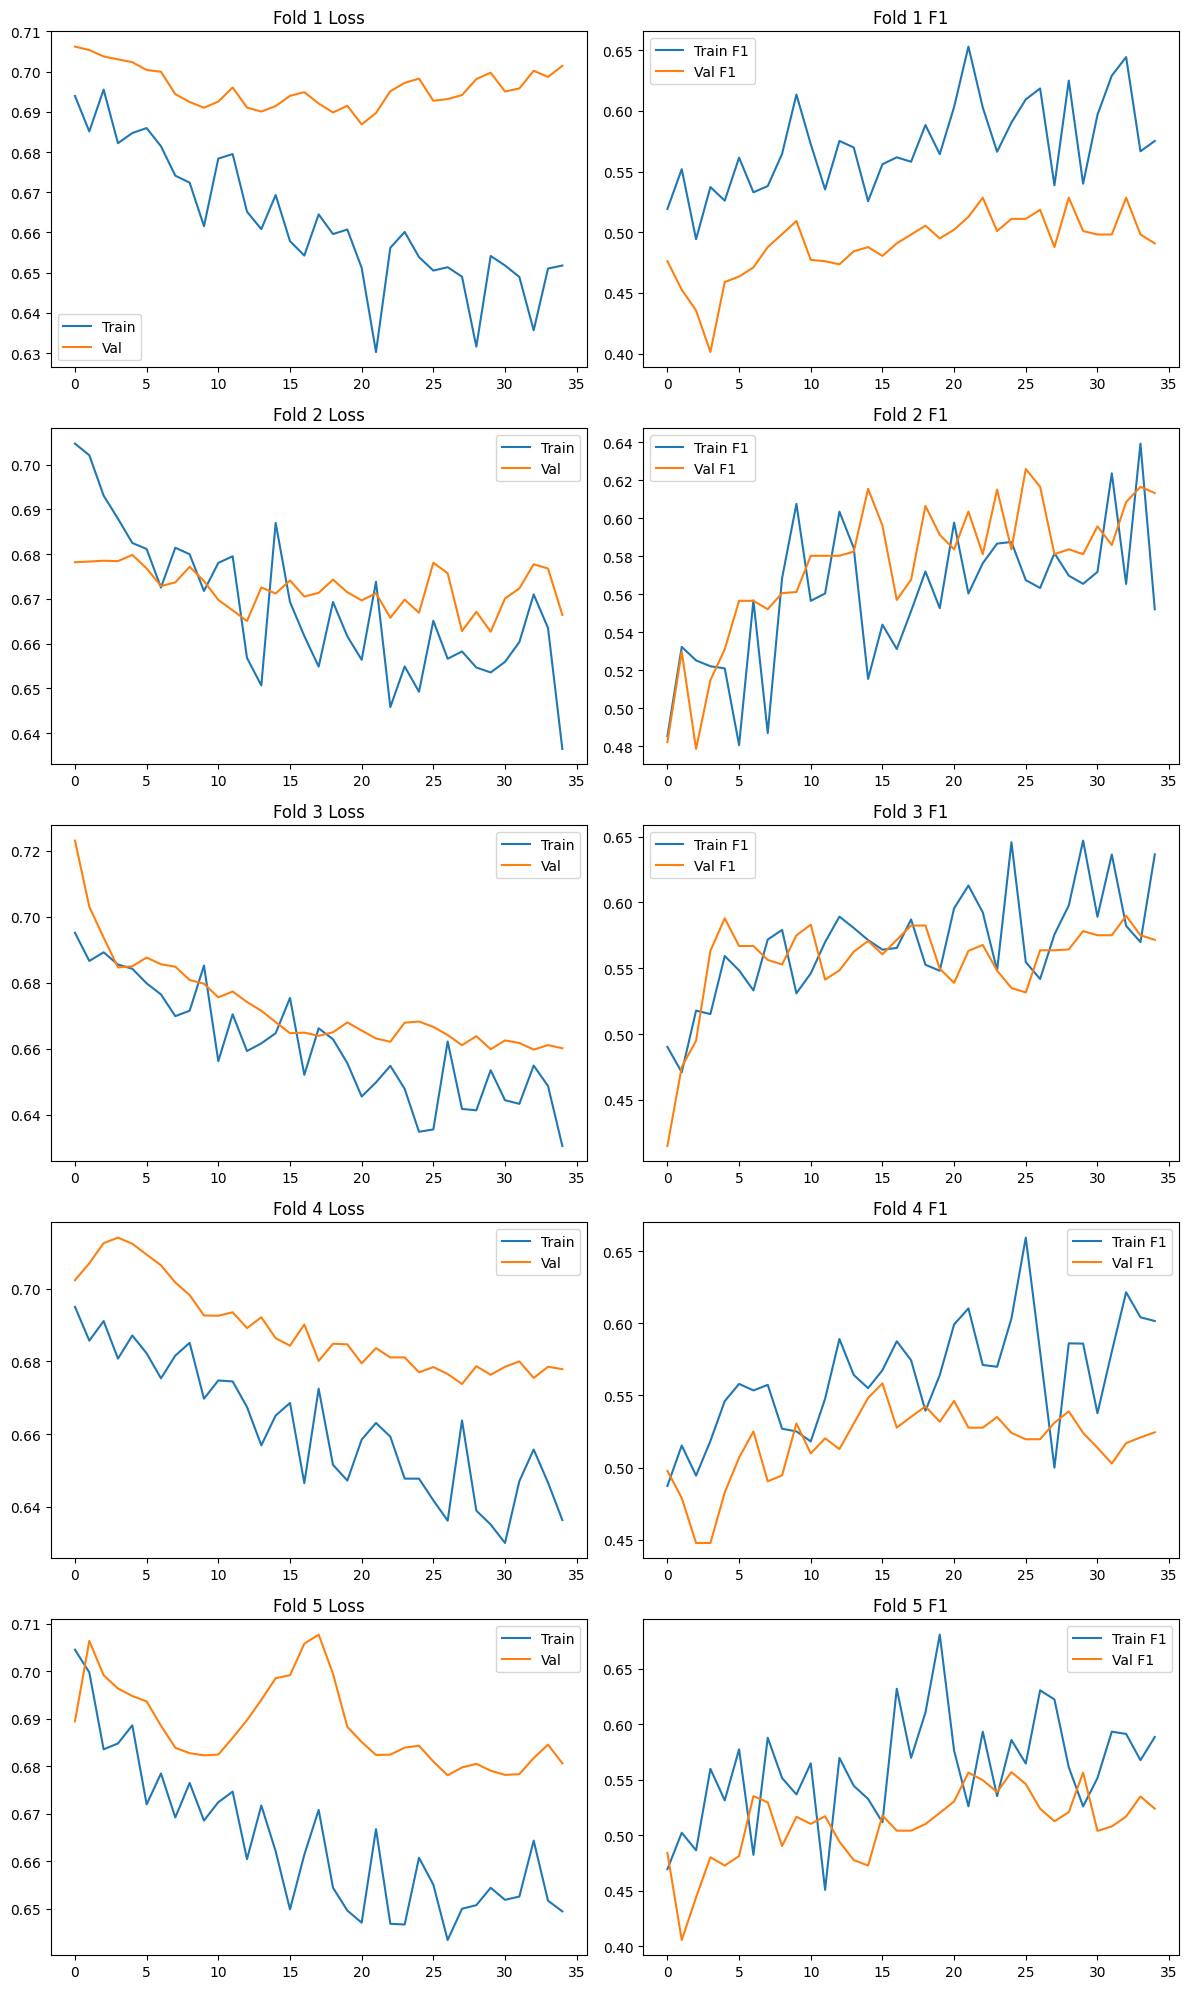

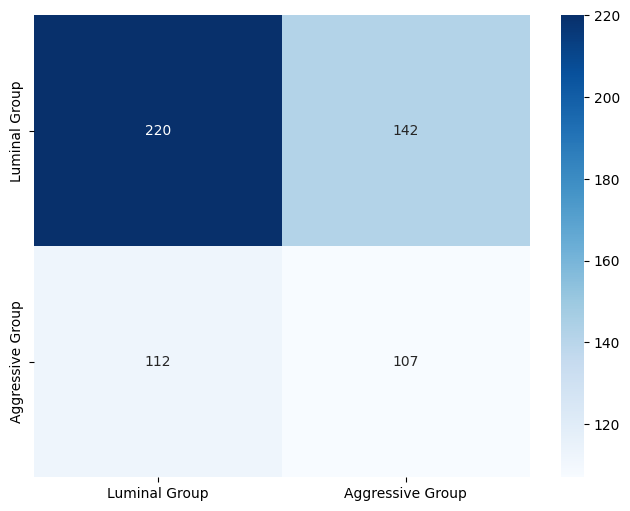

In [53]:
# 2. TRAINING (Called three times, one for each model)
# Train Classifier 1
preds_c1, le_c1 = train_classifier('C1_TRIAGE', DF_FINAL, PRECOMPUTED_DIR)


       STARTING TRAINING FOR: C2_LUMINAL_SUBTYPE: Luminal A vs. Luminal B       
       HPARAMS: {'LR': 5e-05, 'WEIGHT_DECAY': 0.05, 'MIXUP_ALPHA': 0.8}  

=== FOLD 1/5 ===


Ep 1: T_Loss 0.709 | T_F1 0.472 | V_Loss 0.691 | V_F1 0.585


Ep 2: T_Loss 0.698 | T_F1 0.484 | V_Loss 0.693 | V_F1 0.532


Ep 3: T_Loss 0.691 | T_F1 0.488 | V_Loss 0.686 | V_F1 0.545


Ep 4: T_Loss 0.691 | T_F1 0.540 | V_Loss 0.680 | V_F1 0.583


...

Ep 31: T_Loss 0.664 | T_F1 0.600 | V_Loss 0.728 | V_F1 0.582


Ep 32: T_Loss 0.634 | T_F1 0.540 | V_Loss 0.732 | V_F1 0.582


Ep 33: T_Loss 0.640 | T_F1 0.607 | V_Loss 0.734 | V_F1 0.555


Ep 34: T_Loss 0.614 | T_F1 0.678 | V_Loss 0.734 | V_F1 0.569


Ep 35: T_Loss 0.637 | T_F1 0.558 | V_Loss 0.734 | V_F1 0.569
Best Val F1: 0.5830


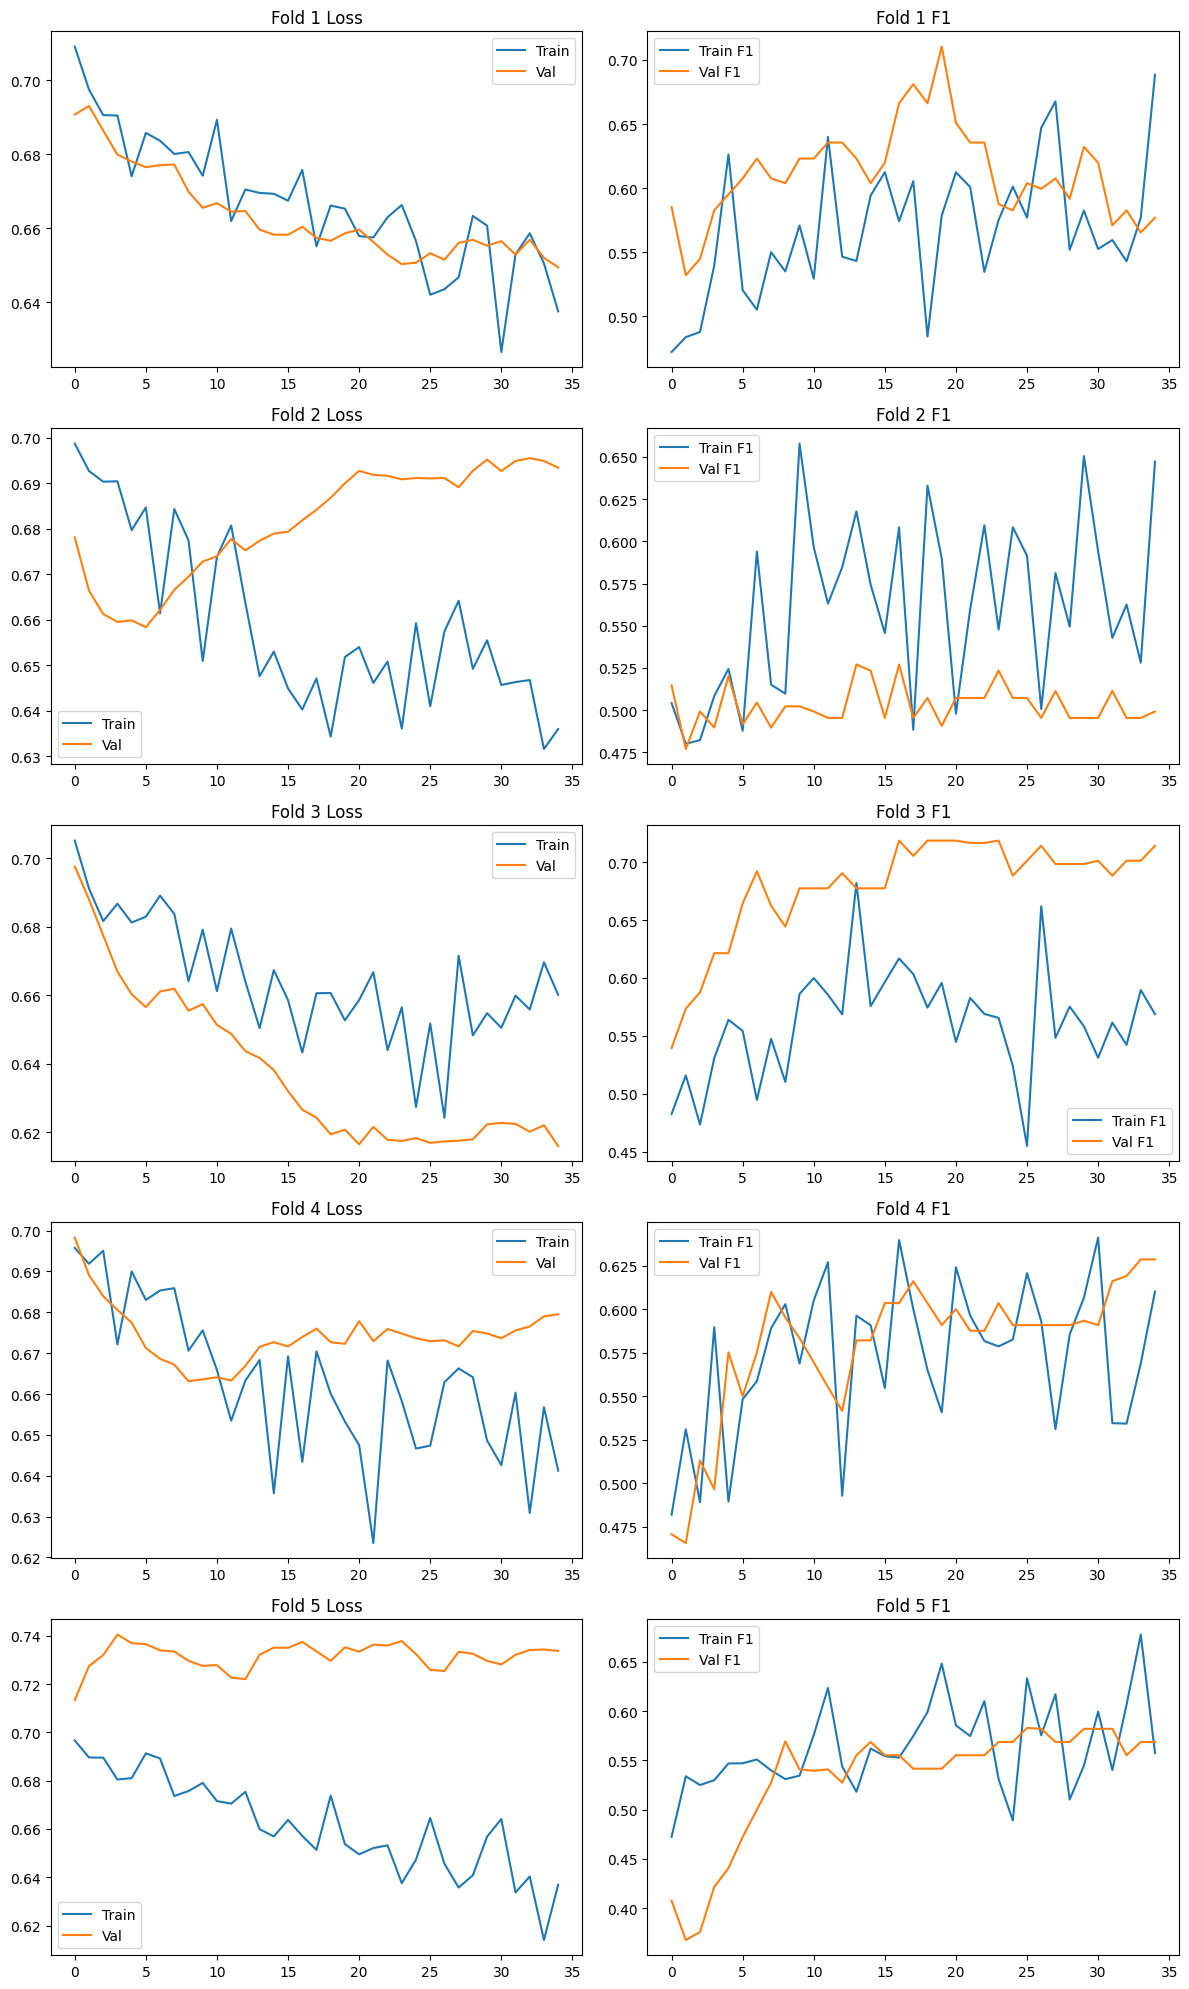

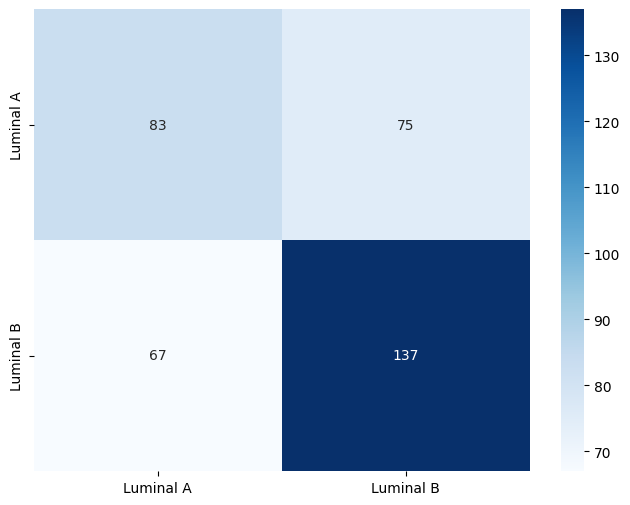

In [54]:
# Train Classifier 2 (Luminal Subtypes)
preds_c2, le_c2 = train_classifier('C2_LUMINAL_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)


       STARTING TRAINING FOR: C3_AGGRESSIVE_SUBTYPE: HER2(+) vs. Triple Negative       
       HPARAMS: {'LR': 0.0001, 'WEIGHT_DECAY': 0.01, 'MIXUP_ALPHA': 0.4}  

=== FOLD 1/5 ===


Ep 1: T_Loss 0.681 | T_F1 0.583 | V_Loss 0.753 | V_F1 0.281


Ep 2: T_Loss 0.692 | T_F1 0.498 | V_Loss 0.733 | V_F1 0.295


Ep 3: T_Loss 0.694 | T_F1 0.557 | V_Loss 0.717 | V_F1 0.305


Ep 4: T_Loss 0.693 | T_F1 0.486 | V_Loss 0.707 | V_F1 0.317


...

Ep 31: T_Loss 0.611 | T_F1 0.625 | V_Loss 0.669 | V_F1 0.449


Ep 32: T_Loss 0.553 | T_F1 0.574 | V_Loss 0.670 | V_F1 0.449


Ep 33: T_Loss 0.561 | T_F1 0.704 | V_Loss 0.673 | V_F1 0.449


Ep 34: T_Loss 0.568 | T_F1 0.641 | V_Loss 0.673 | V_F1 0.449


Ep 35: T_Loss 0.631 | T_F1 0.663 | V_Loss 0.673 | V_F1 0.449
Best Val F1: 0.5559


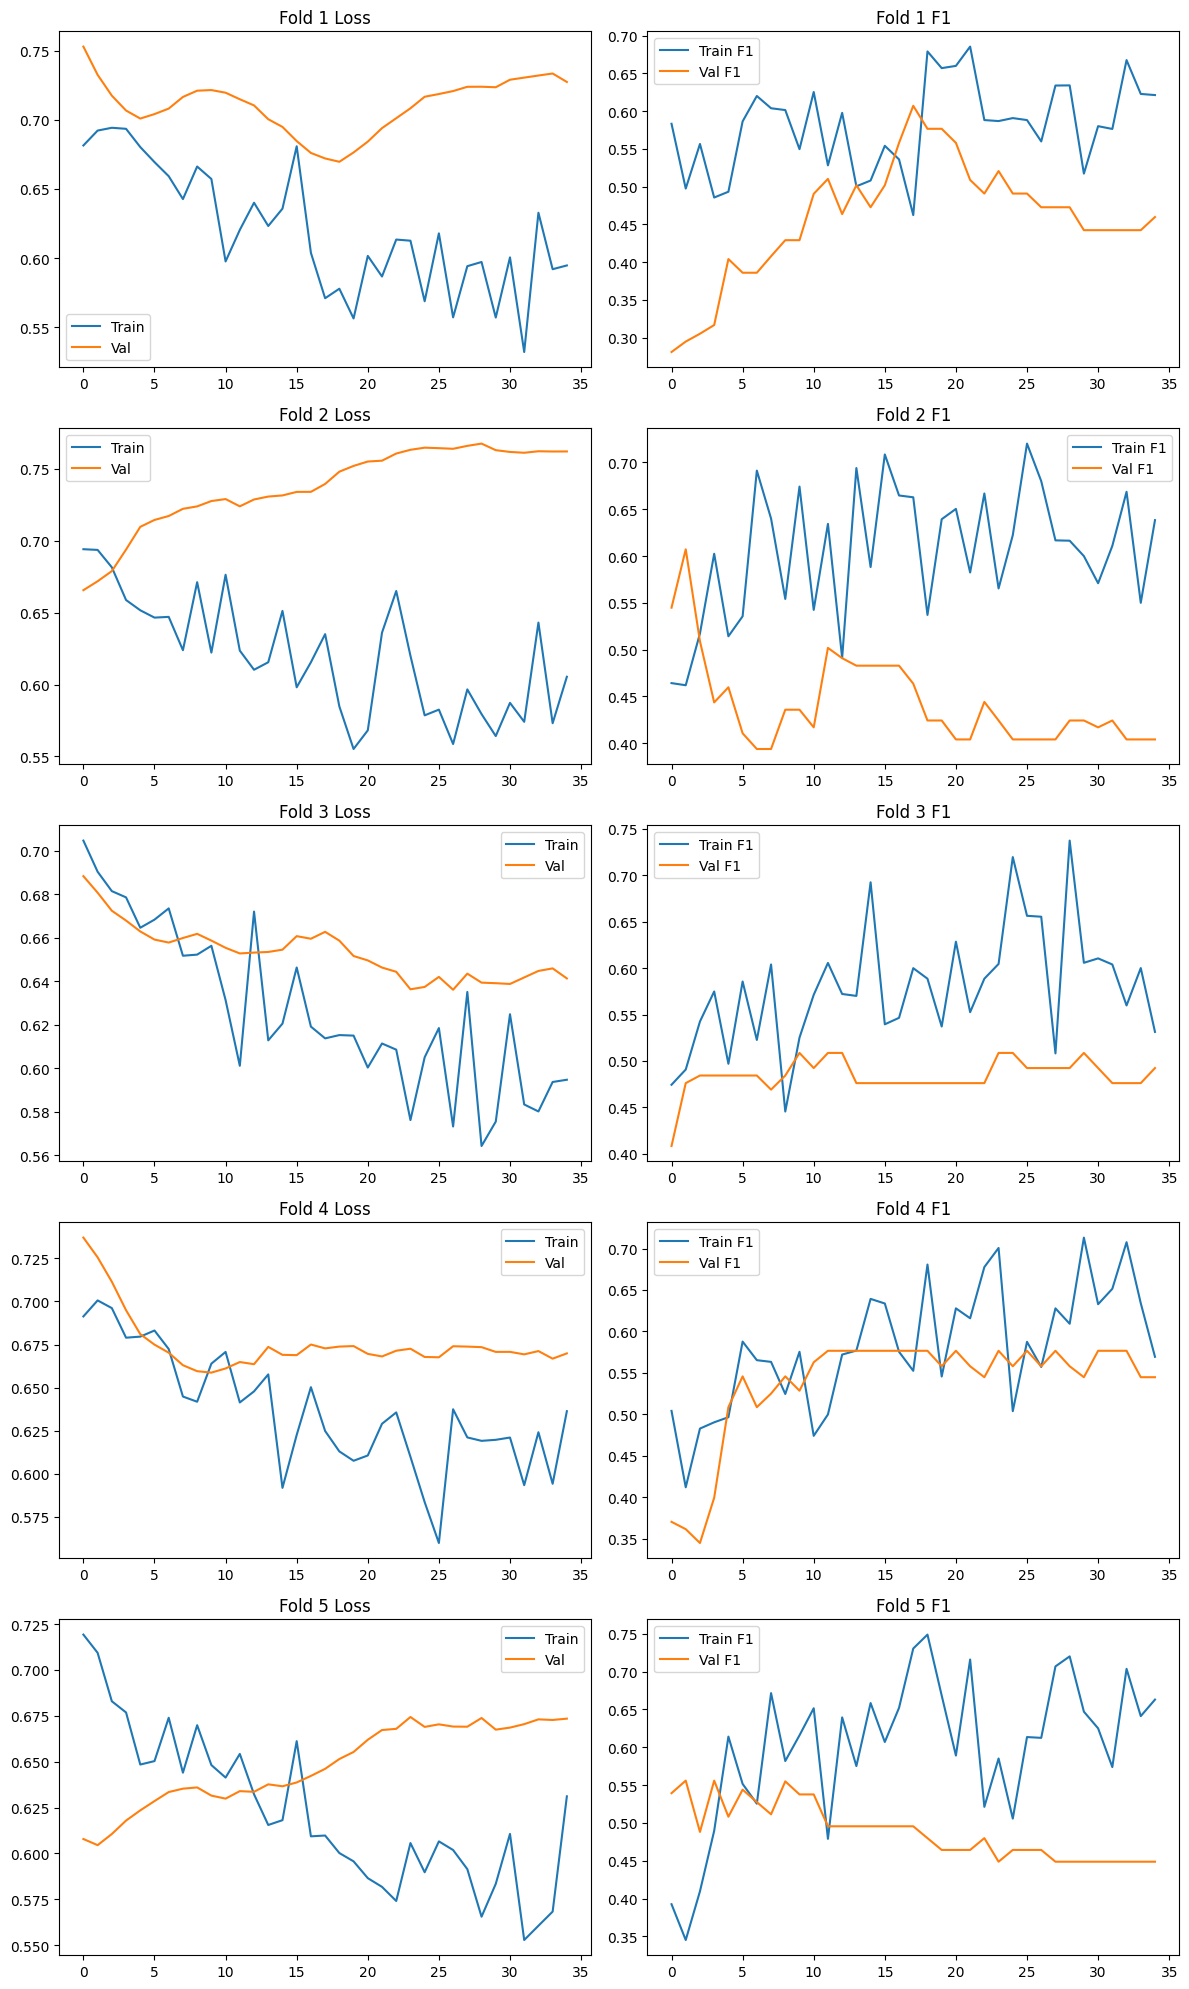

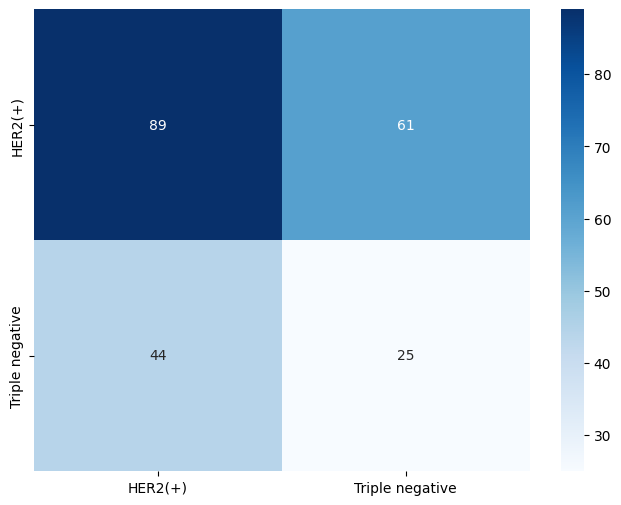

In [55]:
# Train Classifier 3 (Aggressive Subtypes)
preds_c3, le_c3 = train_classifier('C3_AGGRESSIVE_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)

# Tuna salad

In [ ]:
# --- Unified Optuna Objective Function ---
def objective_classifier(trial, classifier_key):
    """
    Defines the search space and runs a single fold of training for the specified classifier.
    Returns the final validation F1 score.
    """
    
    # --- 1. Define Search Space based on the task (Can be adjusted) ---
    hparams = {
        # Search LR (Logarithmic scale is best for LR)
        'LR': trial.suggest_float('LR', 1e-5, 5e-4, log=True),
        # Search WEIGHT_DECAY (L2 Regularization)
        'WEIGHT_DECAY': trial.suggest_float('WEIGHT_DECAY', 1e-4, 1e-1, log=True),
        # Search MIXUP_ALPHA (Strength of data augmentation)
        'MIXUP_ALPHA': trial.suggest_float('MIXUP_ALPHA', 0.2, 0.9)
    }

    # --- 2. Setup Configuration ---
    config = CLASSIFIER_CONFIGS[classifier_key].copy()
    config['hparams'] = hparams # Override hparams with trial suggestions
    
    # --- 3. Prepare Data (Filter for the task) ---
    df_task = DF_FINAL[DF_FINAL[config['label_col']] != -1].reset_index(drop=True)
    
    if len(df_task) == 0:
        print(f"Objective skipped for {classifier_key}: No relevant samples.")
        return 0.0

    # --- 4. Use a single fixed fold for evaluation (Fold 0) ---
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    
    # Get the indices for the first fold (Fold 0)
    try:
        t_idx, v_idx = next(skf.split(df_task, df_task[config['label_col']]))
    except StopIteration:
        print(f"Objective skipped for {classifier_key}: StratifiedKFold failed.")
        return 0.0
        
    # --- 5. Run Training (using the existing train_fold function) ---
    # NOTE: train_fold is expected to correctly use the HPARAMS from the 'config' dict.
    class_names = config['class_names']
    
    h, _, _ = train_fold(
        fold=0, 
        train_idx=t_idx, 
        val_idx=v_idx, 
        df=df_task, 
        le=class_names, # 'le' is used as class_names in train_fold
        precomputed_dir=PRECOMPUTED_DIR, 
        config=config
    )
    
    # --- 6. Return Validation F1 Score ---
    if h is None:
        return 0.0 # Failed trial
    
    # Optuna maximizes the validation F1 score from the last epoch
    return h['v_f1'][-1]

# --- Optuna Study Runner (Wrapper for running the study) ---
def tune_classifier(classifier_key, n_trials=20):
    """
    Sets up and executes the Optuna study for the specified classifier.
    """
    print(f"\n=======================================================")
    print(f"       STARTING OPTUNA TUNING FOR: {classifier_key}          ")
    print(f"       Running {n_trials} trials (using 1 fold/trial)      ")
    print(f"=======================================================")
    
    # Create a wrapper function for the objective that fixes the classifier_key
    func = lambda trial: objective_classifier(trial, classifier_key)
    
    study = optuna.create_study(direction="maximize", study_name=f"tune_{classifier_key}")
    study.optimize(func, n_trials=n_trials)
    
    print(f"\n--- Optuna Study for {classifier_key} Finished ---")
    print(f"Best Trial F1 Score: {study.best_value:.4f}")
    
    best_params = study.best_params
    print("Best Hyperparameters Found:")
    for key, value in best_params.items():
        print(f"  {key}: {value:.6f}")
    
    # Update the global config for the specific classifier
    CLASSIFIER_CONFIGS[classifier_key]['hparams'].update(best_params)
    
    return best_params

In [ ]:
# --- 1. Tune C1: Triage (Luminal vs. Aggressive Group) ---
best_c1_hparams = tune_classifier('C1_TRIAGE', n_trials=30) 


# --- 4. Final Production Training (Saves 5 models for each classifier) ---

print("\n--- Starting FINAL 5-FOLD PRODUCTION TRAINING for all three classifiers ---")

# C1 Final Training (Saves C1_TRIAGE_fold_X_best.pth)
train_classifier('C1_TRIAGE', DF_FINAL, PRECOMPUTED_DIR)

In [ ]:
# --- 2. Tune C2: Luminal Subtyping (Luminal A vs. Luminal B) ---
# Note: C2 usually needs more trials and stronger regularization (MixUp/WD).
best_c2_hparams = tune_classifier('C2_LUMINAL_SUBTYPE', n_trials=40) 

# C2 Final Training (Saves C2_LUMINAL_SUBTYPE_fold_X_best.pth)
train_classifier('C2_LUMINAL_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)

In [ ]:
# --- 3. Tune C3: Aggressive Subtyping (HER2(+) vs. Triple Negative) ---
best_c3_hparams = tune_classifier('C3_AGGRESSIVE_SUBTYPE', n_trials=30) 

# C3 Final Training (Saves C3_AGGRESSIVE_SUBTYPE_fold_X_best.pth)
train_classifier('C3_AGGRESSIVE_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)

In [ ]:
print("\n✅ All 15 models (5 folds x 3 classifiers) saved successfully!")

In [ ]:
# import optuna
# from optuna.samplers import TPESampler
# from sklearn.model_selection import StratifiedKFold
# import torch.optim as optim
# import numpy as np

# # --- 8. OPTUNA OBJECTIVE FUNCTION ---
# # This function wraps the training logic for Optuna to optimize.
# def objective(trial):
#     # Hyperparameter search space
    
#     # 1. Learning Rate (log-uniform is standard for LR)
#     LR = trial.suggest_loguniform('lr', 1e-5, 5e-4, log=True)
    
#     # 2. Weight Decay (L2 Regularization)
#     WEIGHT_DECAY = trial.suggest_loguniform('weight_decay', 1e-4, 1e-2, log=True)
    
#     # 3. MixUp Alpha (Intensity of generalization)
#     MIXUP_ALPHA = trial.suggest_uniform('mixup_alpha', 0.2, 0.8, log=True)
    
#     # Define optimization settings
#     N_OPTI_FOLDS = 2  # Set this to 1 or 2 as desired for speed

#     N_OPTI_EPOCHS = 8  # Use 8 epochs instead of the final 25
    
#     # --- Data and Setup (Reusing code from run()) ---
#     df = pd.read_csv(PATHS['labels'])
#     valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
#     df = df[valid_mask].reset_index(drop=True)

#     # Recreate binary labels (assuming the fix for GROUP_0/GROUP_1 is applied)
#     GROUP_0 = ['Luminal A', 'Luminal B']
#     GROUP_1 = ['HER2(+)', 'Triple Negative'] 
    
#     def get_binary_label(original_label):
#         if original_label in GROUP_0:
#             return 0
#         elif original_label in GROUP_1:
#             return 1
#         else:
#             return -1 # Should not happen with corrected labels
            
#     df['label_binary'] = df['label'].apply(get_binary_label)
#     df['label_encoded'] = df['label_binary']
    
#     # Dummy LabelEncoder is needed for F1 score plotting/context
#     class DummyLabelEncoder:
#         def __init__(self):
#             self.classes_ = ['Group 0 (Luminal A/B)', 'Group 1 (HER2+/TN)']
#         def inverse_transform(self, predictions):
#             return [self.classes_[p] for p in predictions]
            
#     le = DummyLabelEncoder()
    
#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    
#     # Use a fraction of the folds for faster optimization
#     folds_to_use = list(skf.split(df, df['label_binary']))[:N_OPTI_FOLDS]
    
#     fold_f1s = []
    
#     for fold, (t_idx, v_idx) in enumerate(folds_to_use):
        
#         # --- TRAINING LOGIC (Modified train_fold content) ---
#         train_df = df.iloc[t_idx].reset_index(drop=True)
#         val_df = df.iloc[v_idx].reset_index(drop=True)

#         # Class Balancing (using fixed MIXUP_ALPHA)
#         class_counts = train_df['label_encoded'].value_counts().sort_index().values
#         class_weights = 1. / class_counts
#         sample_weights = [class_weights[l] for l in train_df['label_encoded']]
#         sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

#         # IMPORTANT: We need a new get_transforms() call that uses the updated IMG_SIZE
#         # Ensure your external get_transforms() function is correctly using the global IMG_SIZE
#         train_loader = DataLoader(TissueDataset(train_df, PATHS['train_img'], PATHS['train_mask'], get_transforms()[0]), 
#                                   batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
#         val_loader = DataLoader(TissueDataset(val_df, PATHS['train_img'], PATHS['train_mask'], get_transforms()[1]), 
#                                 batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

#         model = get_model(num_classes = 1)
#         optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#         criterion = nn.BCEWithLogitsLoss()
#         #scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        
#         # Training loop is exactly the same as in your train_fold, but with 
#         # the optimized LR, WD, and the new MIXUP_ALPHA (passed via the global scope)
#         best_f1 = 0.0
        
#         for epoch in range(N_OPTI_EPOCHS):
#             model.train()
#             # Training phase
#             t_preds, t_targets = [], []
#             for imgs, lbls in train_loader:
#                 # ... (standard training loop content)
#                 imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#                 optimizer.zero_grad()
                
#                 # --- MIXUP BLOCK ---
#                 lbls_float = lbls.float().unsqueeze(1)
#                 # Pass the trial's MIXUP_ALPHA
#                 imgs, targets_a, targets_b, lam = mixup_data(imgs, lbls_float, MIXUP_ALPHA) 
                
#                 out = model(imgs)
#                 loss = mixup_criterion(criterion, out, targets_a, targets_b, lam)
#                 loss.backward()
#                 optimizer.step()
                
#                 # Metrics accumulation (essential for the F1 score for the epoch)
#                 t_preds.extend((torch.sigmoid(out) >= 0.5).long().squeeze().cpu().numpy())
#                 t_targets.extend(targets_a.round().long().squeeze().cpu().numpy())
                
#             #scheduler.step()
            
#             # Validation phase
#             model.eval()
#             v_preds, v_targets = [], []
#             with torch.no_grad():
#                 for imgs, lbls in val_loader:
#                     imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#                     lbls_float = lbls.float().unsqueeze(1)
#                     out = model(imgs)
                    
#                     v_preds.extend((torch.sigmoid(out) >= 0.5).long().squeeze().cpu().numpy())
#                     v_targets.extend(lbls.cpu().numpy())
            
#             # Calculate F1 for this epoch
#             v_f1 = f1_score(v_targets, v_preds, average='macro')
            
#             if v_f1 > best_f1:
#                 best_f1 = v_f1
#                 # OPTUNA PRUNING: Report intermediate result
#                 # trial.report(best_f1, epoch) # Optionally add pruning later
                
#         # Store the best F1 from this fold
#         fold_f1s.append(best_f1)
        
#     # Optuna aims to maximize the mean F1 score across the N_OPTI_FOLDS
#     return np.mean(fold_f1s)

# # --- 9. OPTUNA EXECUTION ---
# def run_optuna(n_trials=50):
#     # sampler=TPESampler(seed=42) uses Tree-structured Parzen Estimator, good for efficiency
#     study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
#     print(f"Starting Optuna search for {n_trials} trials...")
#     study.optimize(objective, n_trials=n_trials)

#     print("\n--- OPTUNA RESULTS ---")
#     print(f"Best trial value (Mean Macro F1): {study.best_value:.4f}")
#     print("Best hyperparameters found:")
#     for key, value in study.best_params.items():
#         print(f"  {key}: {value}")
    
#     return study.best_params



In [ ]:
# # Example of how to run the optimization:
# best_params = run_optuna(n_trials=50) # Run for 50 combinations
# print(best_params)

# SUBMISSION

In [80]:
# --- ADD THIS TO YOUR GLOBAL CONSTANTS SECTION ---
TEST_PRECOMPUTED_DIR = '/kaggle/working/precomputed_rois_test'

DF_TEST_PROCESSED = None

In [81]:
# --- New Function: Setup Test Data and Preprocess Images ---
def setup_test_data_and_preprocess():
    """
    Finds test image files, runs the heavy CPU precomputation (ROI extraction and 
    Reinhard normalization), and returns the DataFrame of successfully processed test images.
    """
    print("--- 🧠 Test Data Setup & Preprocessing Started ---")
    
    # 1. List Test Files
    test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
    # Create a DataFrame required by preprocess_and_save_images
    test_df = pd.DataFrame({'sample_index': test_files})
    
    # 2. Precompute ROIs, Resize, and Save (Reusing the core logic)
    # We must adapt the existing 'preprocess_and_save_images' slightly 
    # to accept dynamic image/mask paths since it was hardcoded for 'train_img'/'train_mask'.
    
    # --- TEMPORARY FIX: Override PATHS for test processing ---
    # We temporarily create a local path structure that preprocess_and_save_images can use.
    local_paths = {
        'train_img': PATHS['test_img'],    # Source folder for images
        'train_mask': PATHS['test_mask']   # Source folder for masks
    }

    # You must update preprocess_and_save_images in your code to accept and use this local_paths dict
    # (assuming it uses the 'train_img'/'train_mask' keys internally).
    
    df_test_final = preprocess_and_save_images(
        df=test_df, 
        paths=local_paths, # Pass the test paths
        output_dir=TEST_PRECOMPUTED_DIR, 
        img_size=IMG_SIZE
    )
    
    print(f"--- ✅ Test Precomputation Complete. Final test images available: {len(df_test_final)} ---")
    return df_test_final

In [82]:
# --- NEW: Function to Check/Run Test Preprocessing Once ---
def get_processed_test_data():
    """
    Checks if the test data has been processed. If not, runs the heavy preprocessing 
    and stores the resulting DataFrame globally.
    """
    global DF_TEST_PROCESSED
    
    if DF_TEST_PROCESSED is None:
        print("--- ⏳ First call: Running Test Data Preprocessing ---")
        # Call your existing function that does the work (and includes the fix)
        DF_TEST_PROCESSED = setup_test_data_and_preprocess()
        
        if DF_TEST_PROCESSED.empty:
            raise ValueError("Test preprocessing returned an empty DataFrame. Cannot generate submission.")
        print(f"--- ✅ Test Data Stored. Total processed images: {len(DF_TEST_PROCESSED)} ---")
    else:
        print("--- ⏩ Skipping Test Preprocessing (Already done) ---")
        
    return DF_TEST_PROCESSED

In [83]:
# --- New Function: Prediction Helper (TTA + Ensemble for one task) ---
def predict_with_ensemble_tta(loader, model_prefix):
    """
    Loads 5 models (folds) for a specific task and computes the mean prediction
    using 4x TTA. Returns the raw logits/probabilities (for binary class 1).
    """
    models_list = []
    
    # Load 5 folds for the specific model_prefix (e.g., 'C1_TRIAGE_fold_i_best.pth')
    for i in range(N_FOLDS):
        try:
            m = get_model(num_classes=1) # All classifiers are binary (1 output unit)
            # *** Load the model file saved during training ***
            m.load_state_dict(torch.load(f"{model_prefix}_fold_{i}_best.pth")) 
            m.eval()
            models_list.append(m.to(DEVICE))
        except FileNotFoundError:
            print(f"Warning: Model file not found for {model_prefix} fold {i}. Skipping.")
            continue
            
    if not models_list:
        raise ValueError(f"No models found for {model_prefix}. Did you train them first?")

    all_logits = []
    
    with torch.no_grad():
        for imgs, names in tqdm(loader, desc=f"Predicting {model_prefix} (TTA/Ens)"):
            imgs = imgs.to(DEVICE)
            
            # --- TTA: 4 Views (Original, FlipH, FlipV, Rot90) ---
            imgs_lr = torch.flip(imgs, [3])
            imgs_ud = torch.flip(imgs, [2])
            imgs_rot = torch.rot90(imgs, 1, [2, 3])
            
            inputs = [imgs, imgs_lr, imgs_ud, imgs_rot]
            
            # Use 1 unit output (Logits, not probabilities)
            batch_logits = torch.zeros((imgs.size(0), 1)).to(DEVICE)
            
            # Ensemble over 5 Folds + TTA over 4 views
            for m in models_list:
                for inp in inputs:
                    # m(inp) returns logits
                    batch_logits += m(inp)
            
            # Average: Total = (N_FOLDS * N_TTA)
            batch_logits /= (len(models_list) * len(inputs))
            
            all_logits.append(batch_logits.squeeze(1).cpu()) # Store raw logits for majority voting
            
    return torch.cat(all_logits, dim=0)

In [88]:
# --- 7. SUBMISSION (Hierarchical Prediction & TTA/Ensemble) ---
def submit():
    print("--- ⚙️ Generating Submission with Hierarchical TTA/Ensemble ---")
    
    # --- A. DATA SETUP ---

    df_test_processed = get_processed_test_data()
    
    if df_test_processed.empty:
        raise ValueError("Test preprocessing returned an empty DataFrame. Cannot generate submission.")
        
    
    # 2. Setup DataLoader using the processed DataFrame and the correct path
    test_ds = TissueDataset(
        dataframe=df_test_processed,                              # FIX: Use 'dataframe' instead of 'df'
        precomputed_dir=TEST_PRECOMPUTED_DIR,                     # FIX: Use 'precomputed_dir' instead of 'img_dir'
        transform=get_transforms()[1],                            # Validation/Test transforms
        is_test=True, 
        target_label_column='sample_index'                        # Target column is irrelevant for test
    )
    
    loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    # --- B. HIERARCHICAL PREDICTION (C1 -> C2/C3) ---
    
    # 1. Classify C1 (Triage: Luminal Group vs. Aggressive Group)
    # The prefix is the key from CLASSIFIER_CONFIGS
    logits_c1 = predict_with_ensemble_tta(loader, 'C1_TRIAGE')
    
    # C1 prediction (0: Luminal Group, 1: Aggressive Group)
    # We use sigmoid and a threshold (0.5) to get the prediction.
    preds_c1 = (torch.sigmoid(logits_c1) >= 0.5).long() 
    
    
    # 2. Classify C2 (Luminal Subtypes) and C3 (Aggressive Subtypes)
    
    # Initialize the final result array (will hold the final 4-class prediction)
    final_4class_preds = torch.zeros_like(preds_c1, device=DEVICE) # Initialize on device
    
    # --- C2: Predict on Luminal Group (where C1_pred == 0) ---
    luminal_indices = (preds_c1 == 0).nonzero(as_tuple=True)[0]
    
    if len(luminal_indices) > 0:
        # FIX 1: Use df_test_processed instead of undefined test_df
        luminal_df = df_test_processed.iloc[luminal_indices].reset_index(drop=True)
        # FIX 2: C2 prediction must read from TEST_PRECOMPUTED_DIR, not PRECOMPUTED_DIR (which is for train)
        luminal_ds = TissueDataset(
            dataframe=luminal_df, 
            precomputed_dir=TEST_PRECOMPUTED_DIR, 
            transform=get_transforms()[1], 
            is_test=True
        )
        luminal_loader = DataLoader(luminal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        
        logits_c2 = predict_with_ensemble_tta(luminal_loader, 'C2_LUMINAL_SUBTYPE')
        # C2 prediction (0: Luminal A, 1: Luminal B)
        # Final 4-class mapping: 0 -> Luminal A, 1 -> Luminal B
        
        # We need the predictions in the original test_df order (luminal_indices)
        preds_c2 = (torch.sigmoid(logits_c2) >= 0.5).long() # 0 or 1
        
        # Mapping: Luminal A (0) is original class 0, Luminal B (1) is original class 1
        # The final index must be placed back into the final_4class_preds array
        final_4class_preds[luminal_indices] = preds_c2.to(DEVICE) # 0 or 1
        
    
    # --- C3: Predict on Aggressive Group (where C1_pred == 1) ---
    aggressive_indices = (preds_c1 == 1).nonzero(as_tuple=True)[0]
    
    if len(aggressive_indices) > 0:
            # FIX 3: Use df_test_processed instead of undefined test_df
            aggressive_df = df_test_processed.iloc[aggressive_indices].reset_index(drop=True)
            # FIX 4: C3 prediction must read from TEST_PRECOMPUTED_DIR, not PRECOMPUTED_DIR (which is for train)
            aggressive_ds = TissueDataset(
                dataframe=aggressive_df, 
                precomputed_dir=TEST_PRECOMPUTED_DIR, 
                transform=get_transforms()[1], 
                is_test=True
            )
            aggressive_loader = DataLoader(aggressive_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
            
            logits_c3 = predict_with_ensemble_tta(aggressive_loader, 'C3_AGGRESSIVE_SUBTYPE')
            preds_c3 = (torch.sigmoid(logits_c3) >= 0.5).long() # 0 or 1
            
            # Shift binary prediction by +2: 0->2, 1->3
            final_4class_preds[aggressive_indices] = preds_c3.to(DEVICE) + 2
        
    
    # --- C. FINAL OUTPUT MAPPING ---
    
    # Define the final 4 class names (ordered by the index 0, 1, 2, 3)
    FINAL_4CLASS_NAMES = [
        'Luminal A',        # C2_pred == 0
        'Luminal B',        # C2_pred == 1
        'HER2(+)',          # C3_pred == 0 (index 2)
        'Triple negative'   # C3_pred == 1 (index 3)
    ]
    
    # Map the final numerical prediction (0, 1, 2, or 3) back to class strings
    final_labels_text = [FINAL_4CLASS_NAMES[i.item()] for i in final_4class_preds]
    
    # Create Submission File
    submission_df = pd.DataFrame({
        'sample_index': df_test_processed['sample_index'], # Filenames from test_df
        'label': final_labels_text
    })
    
    submission_df.to_csv('submission.csv', index=False)
    print("Done. Submission file 'submission.csv' created.")
    return submission_df

In [ ]:
# # --- 7. SUBMISSION (TTA 4x) ---
# def submit(le):
#     print("Generating Submission with TTA...")
#     test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
#     test_df = pd.DataFrame({'filename': test_files})
    
#     # Dataset di test base
#     test_ds = TissueDataset(test_df, PATHS['test_img'], PATHS['test_mask'], get_transforms()[1], is_test=True)
#     loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
#     models_list = []
#     for i in range(N_FOLDS):
#         m = get_model(len(le.classes_))
#         m.load_state_dict(torch.load(f"fold_{i}_best.pth"))
#         m.eval()
#         models_list.append(m)
        
#     preds, fnames = [], []
    
#     with torch.no_grad():
#         for imgs, names in tqdm(loader):
#             imgs = imgs.to(DEVICE)
            
#             # --- TTA: 4 Viste (Orig, FlipH, FlipV, Rot90) ---
#             imgs_lr = torch.flip(imgs, [3])
#             imgs_ud = torch.flip(imgs, [2])
#             imgs_rot = torch.rot90(imgs, 1, [2, 3])
            
#             inputs = [imgs, imgs_lr, imgs_ud, imgs_rot]
            
#             batch_probs = torch.zeros((imgs.size(0), len(le.classes_))).to(DEVICE)
            
#             # Per ogni modello (Ensemble)
#             for m in models_list:
#                 # Per ogni vista (TTA)
#                 for inp in inputs:
#                     batch_probs += torch.softmax(m(inp), dim=1)
            
#             # Media totale: 5 Fold * 4 TTA = 20 predizioni per immagine
#             batch_probs /= (len(models_list) * len(inputs))
            
#             preds.extend(le.inverse_transform(batch_probs.argmax(1).cpu().numpy()))
#             fnames.extend(names)
            
#     pd.DataFrame({'sample_index': fnames, 'label': preds}).to_csv('submission.csv', index=False)
#     print("Done.")


In [89]:
submit()

--- ⚙️ Generating Submission with Hierarchical TTA/Ensemble ---
--- ⏩ Skipping Test Preprocessing (Already done) ---


Predicting C3_AGGRESSIVE_SUBTYPE (TTA/Ens): 100%|██████████| 4/4 [00:07<00:00,  1.78s/it]

Done. Submission file 'submission.csv' created.


,sample_index,label
0,img_0079.png,Luminal B
1,img_0072.png,Triple negative
2,img_0138.png,HER2(+)
3,img_0068.png,Luminal B
4,img_0049.png,HER2(+)
...,...,...
472,img_0006.png,Triple negative
473,img_0135.png,Luminal B
474,img_0191.png,Luminal B
475,img_0169.png,Luminal B
